# Customer Segmentation

## Importing the dataset

In [ ]:
import pandas as pd

In [ ]:
dataset = pd.read_csv("Wholesale customers data.csv")

In [ ]:
dataset.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## A quick exploration of the data

In [ ]:
dataset.shape

(440, 8)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [ ]:
dataset.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


## Checking histograms

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
spend_cols = ["Fresh","Milk","Grocery","Frozen","Detergents_Paper","Delicassen"]

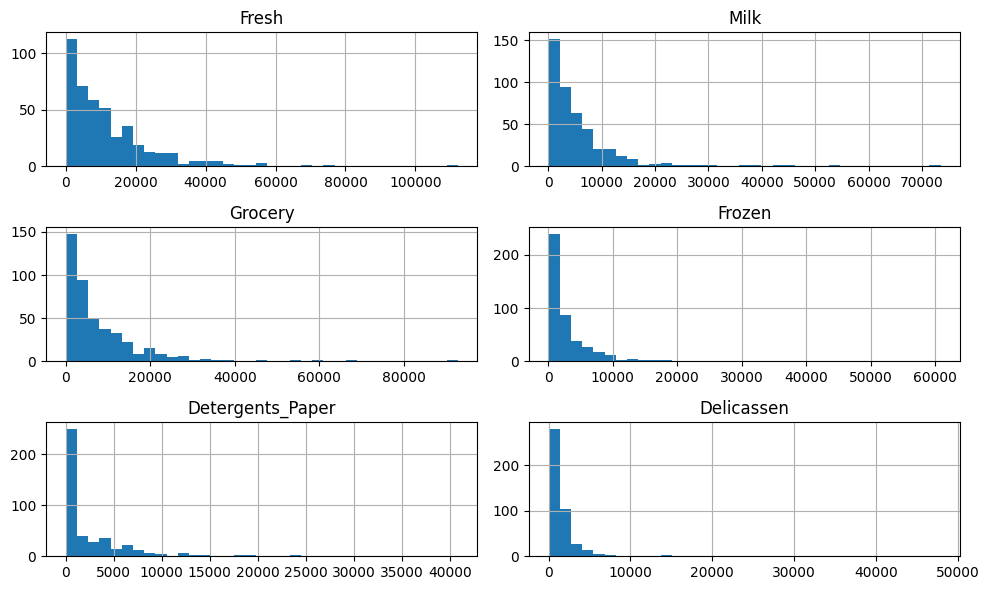

In [ ]:
dataset[spend_cols].hist(bins=35, figsize=(10,6))
plt.tight_layout()

What is scewed data.. what is normal distridution and what is positive distribution.

## Data Preprocessing

In [ ]:
X = dataset[spend_cols]

In [ ]:
X

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...
435,29703,12051,16027,13135,182,2204
436,39228,1431,764,4510,93,2346
437,14531,15488,30243,437,14841,1867
438,10290,1981,2232,1038,168,2125


In [ ]:
import numpy as np

In [ ]:
X_log = np.log1p(X)

In [ ]:
X_log

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718
...,...,...,...,...,...,...
435,10.299037,9.396986,9.682092,9.483112,5.209486,7.698483
436,10.577172,7.266827,6.639876,8.414274,4.543295,7.760893
437,9.584108,9.647885,10.317053,6.082219,9.605216,7.532624
438,9.239025,7.591862,7.711101,6.946014,5.129899,7.661998


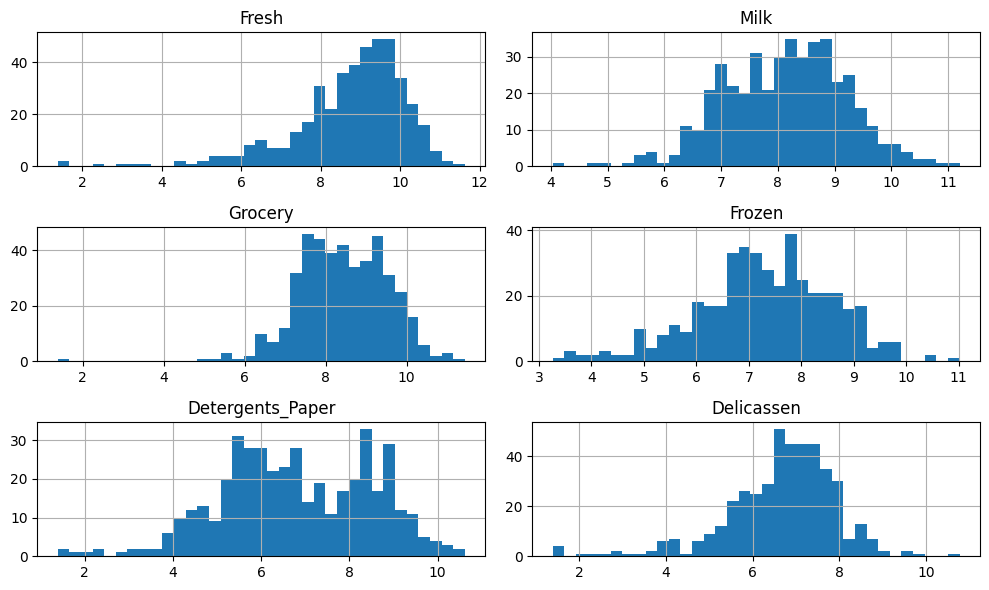

In [ ]:
X_log.hist(bins=35, figsize=(10,6))
plt.tight_layout()

## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

In [ ]:
print(X_scaled)

[[ 0.4861845   0.97629884  0.44015468 -1.50924981  0.64414327  0.40896595]
 [ 0.08788863  0.99095612  0.65217085  0.13405226  0.76604314  0.62792606]
 [ 0.01635628  0.89115098  0.45468702  0.37689926  0.80440496  1.77683339]
 ...
 [ 0.57952767  1.41399051  1.68865731 -0.95351417  1.64761948  0.66656608]
 [ 0.34460869 -0.49078257 -0.65849797 -0.27890118 -0.97324089  0.76666284]
 [-0.54442663 -0.63351532 -0.55281539 -2.43158276 -0.36435895 -2.0896139 ]]


### Finding the Optimum Number of Clusters

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
WCSS = []
Ks= range(1,11)

for i in Ks:
  km = KMeans(n_clusters= i, random_state=42, n_init= "auto")
  km.fit(X_scaled)
  WCSS.append(km.inertia_)


Text(0.5, 1.0, 'Elbow method')

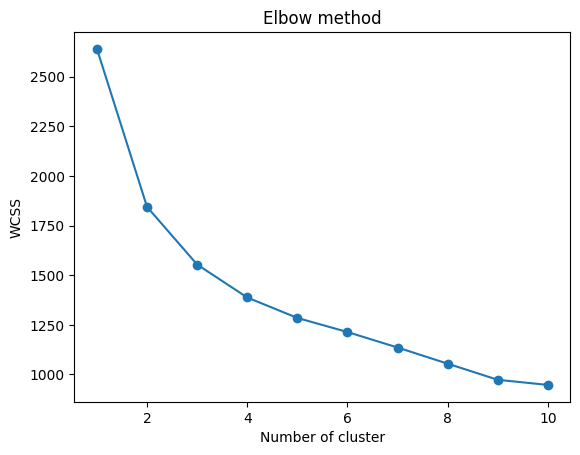

In [ ]:
plt.plot(Ks, WCSS, marker= "o")
plt.xlabel("Number of cluster")
plt.ylabel("WCSS")
plt.title("Elbow method")

## Building the Clustering Model and Finalizing Clusters


### Train K-Means and assign segments

In [ ]:
Kmeans = KMeans(n_clusters= 4, random_state=42, n_init= "auto")
dataset["Segment"] = Kmeans.fit_predict(X_scaled)

### Exporting the segmented dataset

In [ ]:
dataset.to_csv("customer_segments.csv", index= False)

### Value Counts

In [ ]:
dataset["Segment"].value_counts().sort_index()

,count
Segment,
0,70
1,145
2,115
3,110


## Visualize Segments (PCA to 2D)

Need to know more about dimension reduction. for visualizing.

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components= 2)
X_2d = pca.fit_transform(X_scaled)
X_2d

array([[ 1.38038279e+00, -3.04726833e-01],
       [ 1.43886964e+00,  5.37468226e-01],
       [ 1.51345256e+00,  1.23256453e+00],
       [-8.25105399e-01,  1.21078962e+00],
       [ 8.02897108e-01,  1.76604596e+00],
       [ 8.86165465e-01,  1.29894179e-01],
       [ 6.03256020e-01, -4.61548124e-01],
       [ 1.15264871e+00,  6.07676153e-01],
       [ 5.30012066e-01, -6.30138062e-01],
       [ 2.19686557e+00,  3.26049510e-01],
       [ 1.43963779e+00,  5.54203107e-01],
       [-8.44476818e-01, -2.20841715e-02],
       [ 1.88285588e+00,  5.32338198e-01],
       [ 1.35028903e+00,  7.07840715e-01],
       [ 1.81571213e+00,  2.75000938e-01],
       [-6.30635468e-01, -8.08456441e-01],
       [ 1.94097238e+00, -1.65430313e+00],
       [ 1.38588659e-01,  5.40841151e-01],
       [ 1.19332956e+00,  1.22204216e+00],
       [ 5.46470299e-01, -5.44713456e-01],
       [ 5.69829905e-01,  6.69507283e-01],
       [-1.52192160e+00,  7.62767889e-02],
       [-1.65729348e-02,  2.08924555e+00],
       [ 2.

dataset[row(1:4), column(first:last)]
for first to last -> just :

In [ ]:
print(X_2d[0:3,0])

[1.38038279 1.43886964 1.51345256]


In [ ]:
vert_ax_data = X_2d[:,0]
hor_ax_data = X_2d[:,1]

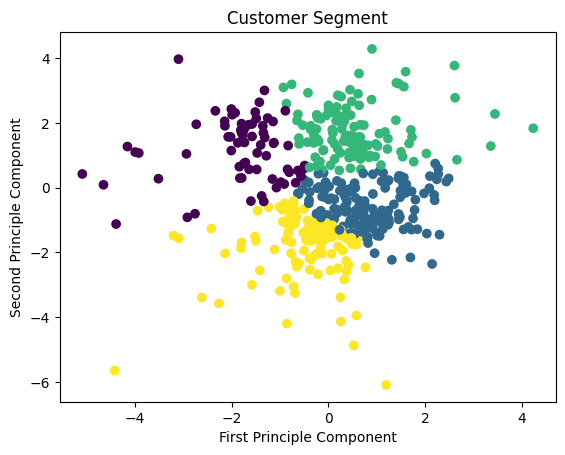

In [ ]:
plt.scatter(hor_ax_data,vert_ax_data, c= dataset["Segment"])
plt.xlabel("First Principle Component")
plt.ylabel("Second Principle Component")
plt.title("Customer Segment")
plt.show()

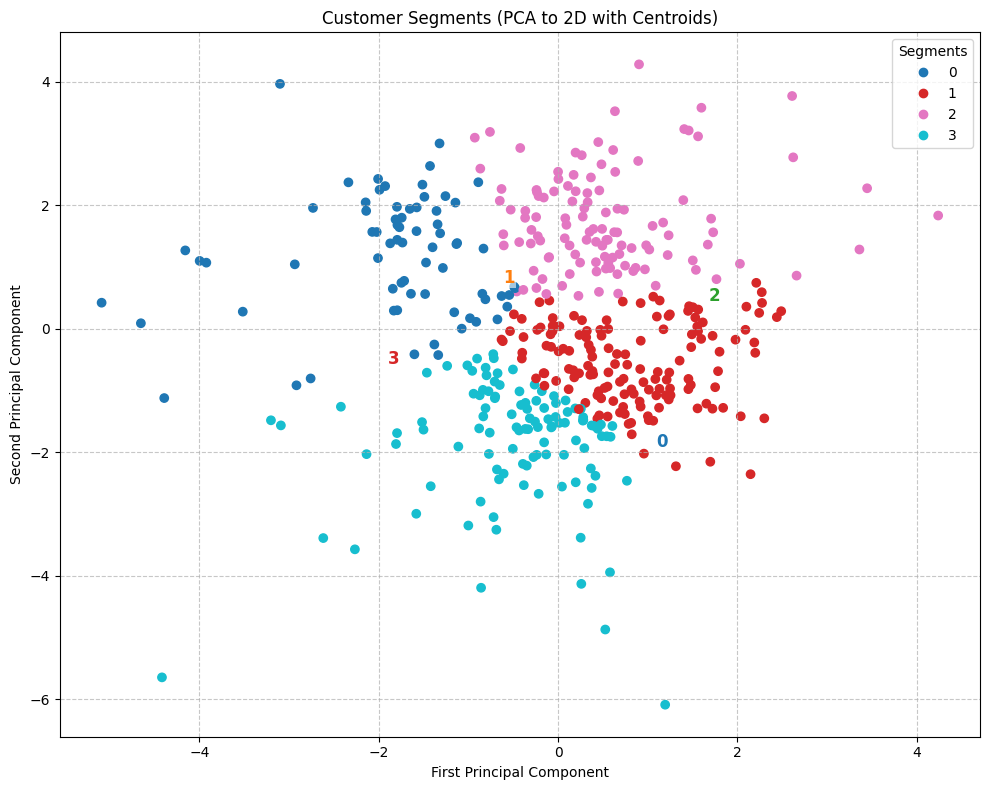

In [59]:
import matplotlib.pyplot as plt

# Define a colormap for consistent coloring
cmap = plt.colormaps['tab10']

plt.figure(figsize=(10, 8))

# Scatter plot: use the defined colormap
scatter = plt.scatter(x=hor_ax_data, y=vert_ax_data, c=dataset['segment'], cmap=cmap)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("Customer Segments (PCA to 2D with Centroids)")

# Get unique segment labels and sort them for consistent indexing with colormap
segments = sorted(dataset['segment'].unique())

# Iterate through each segment to find its centroid and annotate
for segment in segments:
    # Filter data for the current segment
    segment_data = X_2d[dataset['segment'] == segment]
    # Calculate the centroid (mean of x and y coordinates)
    centroid_x = segment_data[:, 0].mean()
    centroid_y = segment_data[:, 1].mean()

    # Get the color for the current segment from the colormap
    # For 'tab10', integer indices directly map to distinct colors
    segment_color = cmap(segment)

    # Annotate the centroid with the segment number, using the segment's color
    plt.text(centroid_x, centroid_y, str(segment),
             fontsize=12, weight='bold', color=segment_color,
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# Get handles and labels for the legend from the scatter plot
handles, _ = scatter.legend_elements()
# Create the legend with custom labels (segment numbers)
plt.legend(handles=handles, labels=[str(s) for s in segments], title="Segments")

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Turn clusters into business friendly personalization

In [61]:
profiles= dataset.groupby("Segment")[spend_cols].median()

Need to clear thisssss.

In [63]:
profiles.div(profiles.sum(axis=1), axis=0).round(3)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Segment,,,,,,
0,0.058,0.280,0.448,0.017,0.183,0.014
1,0.561,0.109,0.126,0.139,0.018,0.047
2,0.230,0.225,0.335,0.039,0.122,0.049
3,0.617,0.084,0.136,0.113,0.017,0.032
